# 07 - Treino DistilBERT (PyTorch)

Treino final fixo com a configuração do script de ensemble, sem Optuna, para poupar tempo.
Treina em `dataset_combined + dataset-exemplos`, faz early stopping em `subm1` e avalia em `subm2`.


In [1]:
import sys
import os
import random
import time

os.environ.setdefault('ROCM_DISABLE_FLUSH_DENORM', '1')
os.environ.setdefault('HIP_VISIBLE_DEVICES', '0')
os.environ.setdefault('TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL', '1')

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

from src.models_pytorch.distilbert import DistilBERTClassifier, DistilBERTDataset, get_tokenizer


In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'HIP_VISIBLE_DEVICES: {os.environ.get("HIP_VISIBLE_DEVICES")}')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU count: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')


HIP_VISIBLE_DEVICES: 0
Device: cuda
  GPU count: 1
  GPU 0: AMD Radeon Graphics


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


## 1. Dados


In [3]:
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
EXEMPLOS_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
EARLY_STOP_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')
EVAL_PATH = os.path.join(ROOT, 'data', 'validation', 'subm2_labels_revealed.csv')
SAVED_MODELS_DIR = os.path.join(ROOT, 'saved_models')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df


df_train = load_data(TRAIN_PATH)
df_exemplos = load_data(EXEMPLOS_PATH)
df_full = pd.concat([df_train, df_exemplos], ignore_index=True)
df_es = load_data(EARLY_STOP_PATH)
df_eval = load_data(EVAL_PATH)

print(f'Train final: {len(df_full)} (combined={len(df_train)} + exemplos={len(df_exemplos)})')
print(f'Early stop (subm1): {len(df_es)}')
print(f'Eval (subm2): {len(df_eval)}')


Train final: 4740 (combined=4615 + exemplos=125)
Early stop (subm1): 100
Eval (subm2): 100


## 2. Tokenizer e Configuração Final


In [4]:
FINAL_BERT_CFG = {
    'lr': 1e-5,
    'batch_size': 8,
    'dropout': 0.1,
    'epochs': 6,
    'max_len': 128,
    'weight_decay': 0.001,
    'patience': 2,
}

tokenizer = get_tokenizer()
print(FINAL_BERT_CFG)


{'lr': 1e-05, 'batch_size': 8, 'dropout': 0.1, 'epochs': 6, 'max_len': 128, 'weight_decay': 0.001, 'patience': 2}


## 3. Funções


In [5]:
def evaluate_probs(probs, labels, name):
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}')
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.tight_layout()
    plt.show()
    return acc, macro_f1, preds


def predict_bert(model, texts, labels, tokenizer, batch_size, max_len):
    ds = DistilBERTDataset(texts, labels, tokenizer, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size)
    probs = []

    model.eval()
    with torch.no_grad():
        for batch in dl:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            logits = model(input_ids, attention_mask)
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())

    return np.vstack(probs)


## 4. Treino Final


In [6]:
class_counts = np.bincount(df_full['label_id'].values, minlength=NUM_CLASSES)
inv_freq = 1.0 / np.maximum(class_counts, 1)
class_weights = torch.tensor(inv_freq / inv_freq.sum() * NUM_CLASSES, dtype=torch.float32)
print(f'Class weights: {class_weights.numpy()}')

train_dl = DataLoader(
    DistilBERTDataset(df_full['Text'].tolist(), df_full['label_id'].values, tokenizer, max_len=FINAL_BERT_CFG['max_len']),
    batch_size=FINAL_BERT_CFG['batch_size'],
    shuffle=True,
)
es_dl = DataLoader(
    DistilBERTDataset(df_es['Text'].tolist(), df_es['label_id'].values, tokenizer, max_len=FINAL_BERT_CFG['max_len']),
    batch_size=FINAL_BERT_CFG['batch_size'],
)

final_bert_model = DistilBERTClassifier(
    output_dim=NUM_CLASSES,
    dropout=FINAL_BERT_CFG['dropout'],
    freeze_bert=False,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = torch.optim.AdamW(
    final_bert_model.parameters(),
    lr=FINAL_BERT_CFG['lr'],
    weight_decay=FINAL_BERT_CFG['weight_decay'],
)

best_es_acc = 0.0
best_state = None
patience_counter = 0
start = time.time()

for epoch in range(FINAL_BERT_CFG['epochs']):
    final_bert_model.train()
    train_correct = 0
    train_total = 0

    for batch_idx, batch in enumerate(train_dl):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labs = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        logits = final_bert_model(input_ids, attention_mask)
        loss = criterion(logits, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(final_bert_model.parameters(), 1.0)
        optimizer.step()

        train_correct += (logits.argmax(dim=1) == labs).sum().item()
        train_total += len(labs)

    final_bert_model.eval()
    es_correct = 0
    es_total = 0
    with torch.no_grad():
        for batch in es_dl:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE)
            logits = final_bert_model(input_ids, attention_mask)
            es_correct += (logits.argmax(dim=1) == labs).sum().item()
            es_total += len(labs)

    es_acc = es_correct / es_total
    train_acc = train_correct / train_total
    print(f'Epoch {epoch + 1}/{FINAL_BERT_CFG["epochs"]}: train_acc={train_acc:.4f} es_acc={es_acc:.4f}')

    if es_acc > best_es_acc:
        best_es_acc = es_acc
        best_state = {k: v.detach().cpu().clone() for k, v in final_bert_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= FINAL_BERT_CFG['patience']:
            print(f'Early stopping na epoch {epoch + 1}')
            break

if best_state is not None:
    final_bert_model.load_state_dict(best_state)
final_bert_model.to(DEVICE)

train_time = time.time() - start
print(f'Tempo total: {train_time:.1f}s')


Class weights: [1.0158532  0.9187716  0.88730085 0.9178673  1.260207  ]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/6: train_acc=0.7928 es_acc=0.5800
Epoch 2/6: train_acc=0.9365 es_acc=0.6300
Epoch 3/6: train_acc=0.9671 es_acc=0.6700
Epoch 4/6: train_acc=0.9783 es_acc=0.6700
Epoch 5/6: train_acc=0.9905 es_acc=0.6200
Early stopping na epoch 5
Tempo total: 624.4s


## 5. Avaliação



=== DistilBERT - ES (subm1) ===
Accuracy: 0.6700 | Macro F1: 0.5944
              precision    recall  f1-score   support

   Anthropic       0.80      0.47      0.59        17
      Google       0.56      0.29      0.38        17
       Human       0.78      0.91      0.84        34
        Meta       0.67      1.00      0.80        18
      OpenAI       0.36      0.36      0.36        14

    accuracy                           0.67       100
   macro avg       0.63      0.61      0.59       100
weighted avg       0.66      0.67      0.64       100



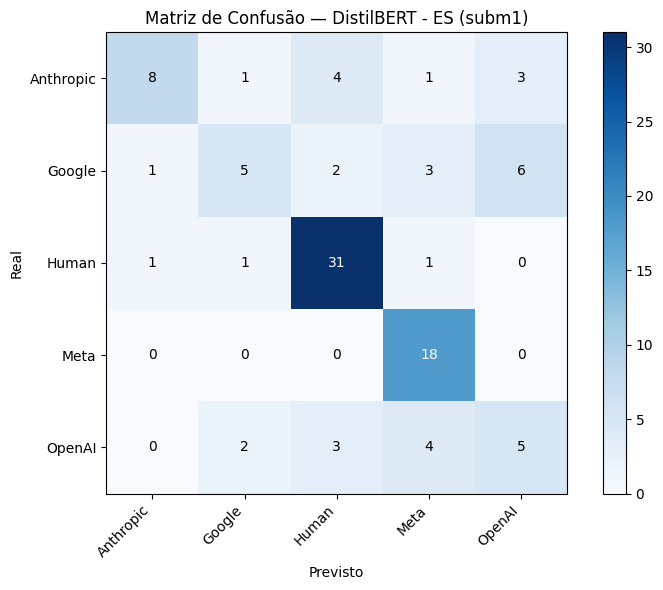


=== DistilBERT - Eval (subm2) ===
Accuracy: 0.6200 | Macro F1: 0.5891
              precision    recall  f1-score   support

   Anthropic       1.00      0.44      0.61        16
      Google       0.47      0.44      0.46        18
       Human       0.78      0.74      0.76        34
        Meta       0.56      0.94      0.70        16
      OpenAI       0.41      0.44      0.42        16

    accuracy                           0.62       100
   macro avg       0.64      0.60      0.59       100
weighted avg       0.67      0.62      0.62       100



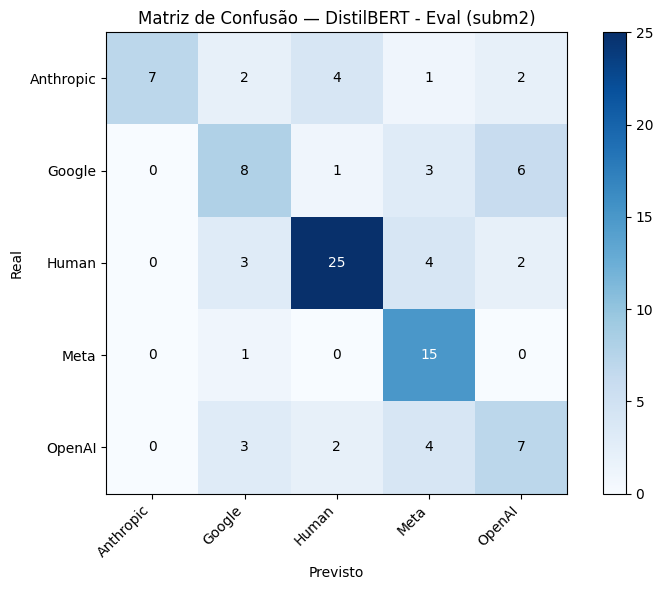

In [7]:
probs_es = predict_bert(
    final_bert_model,
    df_es['Text'].tolist(),
    df_es['label_id'].values,
    tokenizer,
    FINAL_BERT_CFG['batch_size'],
    FINAL_BERT_CFG['max_len'],
)

probs_eval = predict_bert(
    final_bert_model,
    df_eval['Text'].tolist(),
    df_eval['label_id'].values,
    tokenizer,
    FINAL_BERT_CFG['batch_size'],
    FINAL_BERT_CFG['max_len'],
)

es_acc, es_f1, _ = evaluate_probs(probs_es, df_es['label_id'].values, 'DistilBERT - ES (subm1)')
eval_acc, eval_f1, _ = evaluate_probs(probs_eval, df_eval['label_id'].values, 'DistilBERT - Eval (subm2)')


## 6. Guardar Pesos


In [8]:
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
model_path = os.path.join(SAVED_MODELS_DIR, 'distilbert_final_model.pt')
torch.save(final_bert_model.state_dict(), model_path)
print(f'Modelo guardado em {model_path}')


Modelo guardado em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/saved_models/distilbert_final_model.pt
